In [1]:
import json, glob, numpy as np, pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

CLS = ['Benign','BruteForce','DDoS','DoS','Mirai','Recon','Spoofing','Web']

def load(name):
    hits = glob.glob(f"/kaggle/**/{name}.json", recursive=True)
    if not hits:
        print(f"  MISSING: {name}"); return None
    d = json.load(open(hits[0]))
    print(f"  {name:26s} {len(d):3d} records")
    return d

print("Loading:")
thr   = load("threshold_analysis")
resc  = load("rescued_perclass")
stab  = load("stability_results")
focal = load("focal_stability_results")
full  = load("results_full")

Loading:
  threshold_analysis          20 records
  rescued_perclass            20 records
  stability_results           40 records
  focal_stability_results     20 records
  results_full                30 records


In [2]:
rows = []
for r in thr:
    for c, v in r["per_class"].items():
        rows.append({"strategy": r["strategy"], "seed": r["seed"], "class": c, **v})
T = pd.DataFrame(rows)

print("PR-AUC (threshold-free) vs argmax-F1 vs best-threshold F1\n")
print(f"{'class':<12}{'metric':<12}{'CE':>18}{'Focal':>18}{'p':>10}")
print("-"*70)
for c in CLS:
    for m in ["pr_auc", "argmax_f1", "best_f1"]:
        a = T[(T["class"]==c) & (T.strategy=="none")][m].values
        b = T[(T["class"]==c) & (T.strategy=="focal")][m].values
        if len(a)==0 or len(b)==0: continue
        p = stats.mannwhitneyu(a, b).pvalue
        star = "*" if p < 0.05 else " "
        print(f"{c:<12}{m:<12}{a.mean():>9.4f}+/-{a.std(ddof=1):<7.4f}"
              f"{b.mean():>9.4f}+/-{b.std(ddof=1):<7.4f}{p:>9.3f}{star}")
    print()

PR-AUC (threshold-free) vs argmax-F1 vs best-threshold F1

class       metric                      CE             Focal         p
----------------------------------------------------------------------
Benign      pr_auc         0.8343+/-0.0372    0.8387+/-0.0040     0.186 
Benign      argmax_f1      0.7107+/-0.1948    0.7815+/-0.0119     0.970 
Benign      best_f1        0.7817+/-0.0327    0.7846+/-0.0059     0.307 

BruteForce  pr_auc         0.2354+/-0.0279    0.1813+/-0.0776     0.089 
BruteForce  argmax_f1      0.2676+/-0.0193    0.0985+/-0.0279     0.000*
BruteForce  best_f1        0.2769+/-0.0193    0.2516+/-0.0337     0.041*

DDoS        pr_auc         0.9280+/-0.0674    0.9053+/-0.0036     0.473 
DDoS        argmax_f1      0.7219+/-0.2806    0.7664+/-0.0231     0.345 
DDoS        best_f1        0.8743+/-0.1073    0.8186+/-0.0043     0.385 

DoS         pr_auc         0.8679+/-0.1453    0.8655+/-0.0043     0.734 
DoS         argmax_f1      0.7946+/-0.1616    0.8086+/-0.0089     

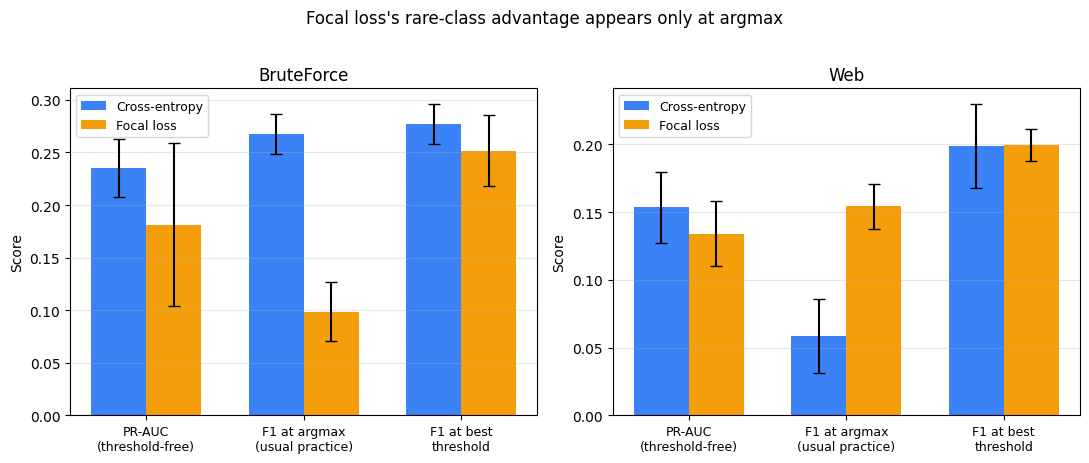

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
for ax, c in zip(axes, ["BruteForce", "Web"]):
    metrics = ["pr_auc", "argmax_f1", "best_f1"]
    labels  = ["PR-AUC\n(threshold-free)", "F1 at argmax\n(usual practice)", "F1 at best\nthreshold"]
    x = np.arange(3); w = 0.35
    for i, (s, col, nm) in enumerate([("none","#3b82f6","Cross-entropy"),
                                      ("focal","#f59e0b","Focal loss")]):
        d = T[(T["class"]==c) & (T.strategy==s)]
        mu = [d[m].mean() for m in metrics]
        sd = [d[m].std(ddof=1) for m in metrics]
        ax.bar(x+i*w, mu, w, yerr=sd, capsize=4, label=nm, color=col)
    ax.set_xticks(x+w/2); ax.set_xticklabels(labels, fontsize=9)
    ax.set_ylabel("Score"); ax.set_title(f"{c}")
    ax.grid(alpha=.3, axis='y'); ax.legend(fontsize=9)
plt.suptitle("Focal loss's rare-class advantage appears only at argmax", y=1.02)
plt.tight_layout()
plt.savefig("/kaggle/working/fig_threshold_artifact.png", dpi=200, bbox_inches='tight')
plt.show()

In [5]:
import numpy as np, pandas as pd

def block(recs, label, use_rescued=False):
    a = "rescued_accuracy" if use_rescued else "accuracy"
    b = "rescued_balanced_accuracy" if use_rescued else "balanced_accuracy"
    acc = np.array([r[a] for r in recs]); bal = np.array([r[b] for r in recs])
    return {"condition": label, "n": len(acc),
            "accuracy": f"{acc.mean():.4f} ± {acc.std(ddof=1):.4f}",
            "bal_acc":  f"{bal.mean():.4f} ± {bal.std(ddof=1):.4f}",
            "acc_range": f"{acc.min():.3f}–{acc.max():.3f}"}

ceA = [r for r in stab if r["protocol"]=="A"]
ceB = [r for r in stab if r["protocol"]=="B"]
rn  = [r for r in resc if r["strategy"]=="none"]
rf  = [r for r in resc if r["strategy"]=="focal"]

rows = [
    block(ceA, "CE, protocol A, final epoch"),
    block(ceA, "CE, protocol A, val-selected", True),
    block(ceB, "CE, protocol B, final epoch"),
    block(ceB, "CE, protocol B, val-selected", True),
    block(rf,  "Focal, protocol B, final epoch"),
    block(rf,  "Focal, protocol B, val-selected", True),
]
print(pd.DataFrame(rows).to_string(index=False))

                      condition  n        accuracy         bal_acc   acc_range
    CE, protocol A, final epoch 20 0.8139 ± 0.0543 0.6301 ± 0.0374 0.692–0.880
   CE, protocol A, val-selected 20 0.8759 ± 0.0075 0.6731 ± 0.0063 0.855–0.887
    CE, protocol B, final epoch 20 0.8158 ± 0.0614 0.6292 ± 0.0480 0.604–0.883
   CE, protocol B, val-selected 20 0.8737 ± 0.0091 0.6718 ± 0.0075 0.848–0.886
 Focal, protocol B, final epoch 10 0.7611 ± 0.0096 0.7088 ± 0.0067 0.745–0.774
Focal, protocol B, val-selected 10 0.7624 ± 0.0094 0.7088 ± 0.0057 0.745–0.776
